In [24]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

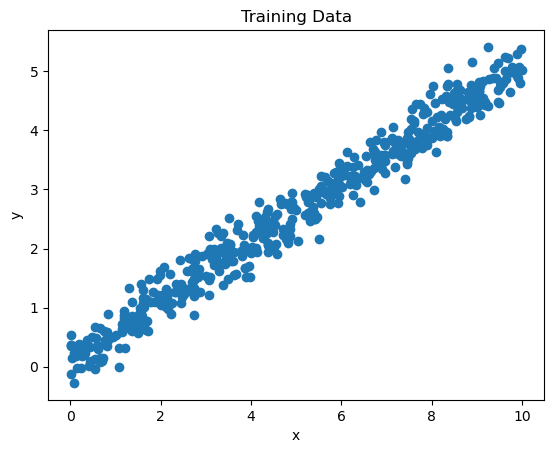

In [29]:
#create data set
m = 0.5
b = 0.13

sigma = 0.25

num_points = 500

x_train = np.random.uniform(0,10,num_points)
y_train = m * x_train + b
y_train = y_train + np.random.normal(0,sigma,size=len(y_train))

x_test = np.random.uniform(0,10,int(np.floor(num_points * 0.2)))
y_test = m * x_test + b
y_test = y_test + np.random.normal(0,sigma,size=len(y_test))

plt.scatter(x_train,y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')
plt.show()

In [30]:
#build NN for regression
model = keras.models.Sequential([
    keras.layers.Dense(30, input_dim=1, activation='relu'),
    keras.layers.Dropout(rate=0.1),
    keras.layers.Dense(1, activation='linear')
])

model.compile(loss='mean_squared_error', optimizer='sgd', metrics=['mse','mae'])

history = model.fit(x_train,y_train,epochs=50)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8956 - mae: 1.5994 - mse: 5.8956    
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2919 - mae: 0.3819 - mse: 0.2919 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2035 - mae: 0.3566 - mse: 0.2035 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2073 - mae: 0.3490 - mse: 0.2073 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2307 - mae: 0.3543 - mse: 0.2307 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1913 - mae: 0.3247 - mse: 0.1913 
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1702 - mae: 0.3120 - mse: 0.1702 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1568 - mae: 0.3098 - mse: 0.1568 
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1751 - mae: 0.3206 - mse: 0.1751 
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1558 - mae: 0.3042 - mse: 0.1558 
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


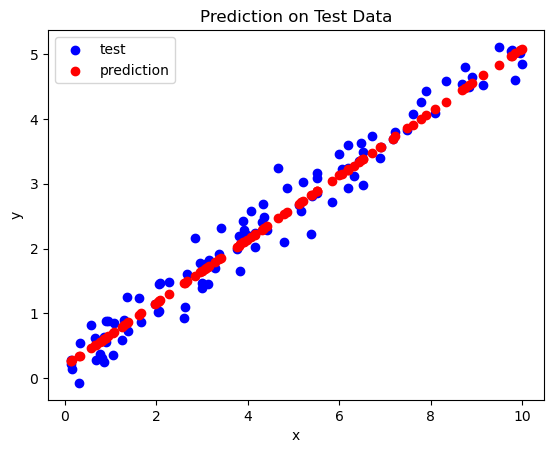

In [31]:
y_pred = model.predict(tf.convert_to_tensor(x_test))
plt.scatter(x_test,y_test,c='b', label='test')
plt.scatter(x_test,y_pred,c='r', label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prediction on Test Data')
plt.legend()
plt.show()

In [32]:
mse = tf.keras.metrics.MeanSquaredError()
mse.update_state(y_pred, y_test)
print(f'MSE: {mse.result().numpy()}')

MSE: 0.06507185101509094
